What are thre most demanded skills for three most popular data roles?

Methodology

1.Clean_up skill column
2.Calculate skill count based on job_title_short
3.Calculate skill percentage
4.Plot final findings


In [51]:
# Importing Libraries
import ast
import pandas as pd
import seaborn as sns
from datasets import load_dataset
import matplotlib.pyplot as plt

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

#Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [38]:
df_Canada = df[df['job_country'] == 'Canada']

In [39]:
df_skills = df_Canada.explode('job_skills')

df_skills[['job_title', 'job_skills']]

,job_title,job_skills
50,Sr ML Engineer - Research & NLP (Remote),python
50,Sr ML Engineer - Research & NLP (Remote),sql
50,Sr ML Engineer - Research & NLP (Remote),pytorch
50,Sr ML Engineer - Research & NLP (Remote),pandas
59,Data Engineer with Dremio Experience,sql
...,...,...
785511,Data Engineer,spark
785511,Data Engineer,airflow
785511,Data Engineer,kafka
785643,Analyste,word


In [40]:
df_skills_count = df_skills.groupby(['job_skills', 'job_title_short']).size()

df_skills_count = df_skills_count.reset_index(name ='skill_count')

df_skills_count.sort_values(by='skill_count',ascending=False, inplace=True)

df_skills_count

,job_skills,job_title_short,skill_count
1215,sql,Data Engineer,3794
949,python,Data Engineer,3567
108,azure,Data Engineer,2217
98,aws,Data Engineer,2030
1171,spark,Data Engineer,1948
...,...,...,...
749,no-sql,Cloud Engineer,1
748,no-sql,Business Analyst,1
671,mattermost,Senior Data Analyst,1
1439,webex,Data Scientist,1


In [41]:
job_titles = df_skills_count['job_title_short'].unique().tolist()

job_titles = sorted(job_titles[:3])

job_titles

['Data Analyst', 'Data Engineer', 'Senior Data Engineer']

In [42]:
fig, ax = plt.subplots(len(job_titles), 1)

for i, job_title in enumerate(job_titles);
    df_plot = df_skills_count[df_skills_count['job_title_short'] == job_title].head(5)
    df_plot.plot(kind='barh', x='job_skills', y='skill_count', ax=ax[i],title = job_title)

SyntaxError: invalid syntax (868005511.py, line 3)

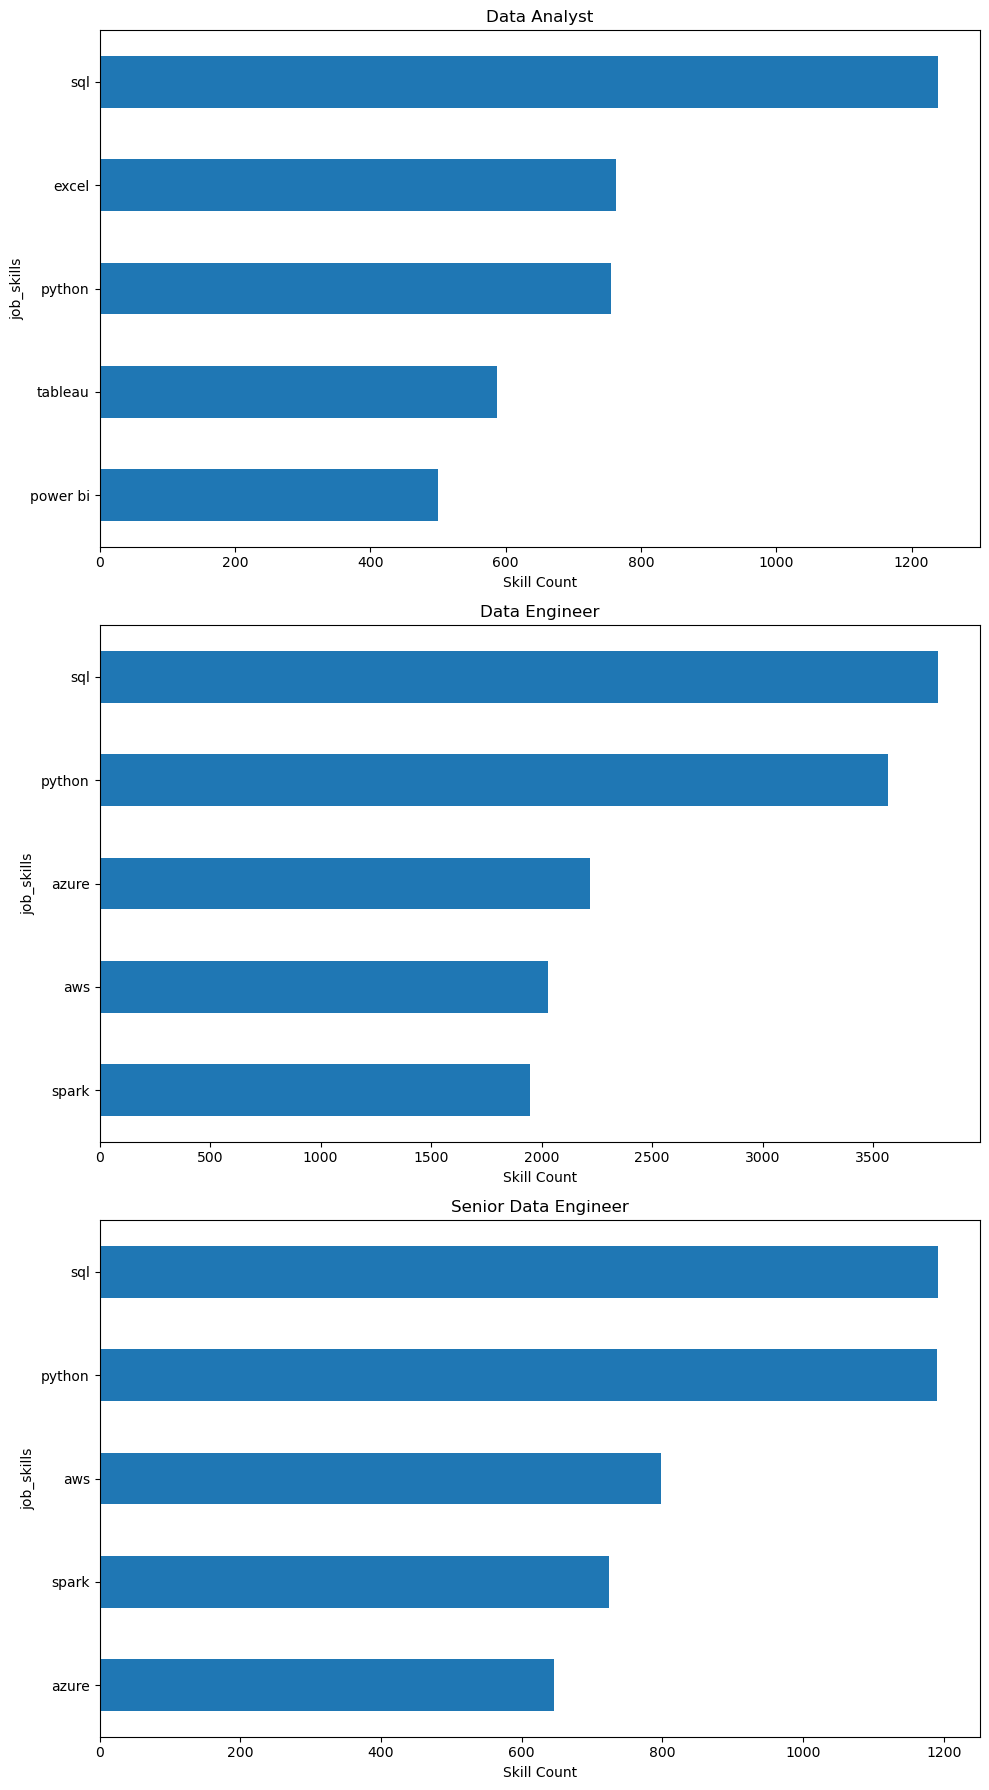

In [ ]:
fig, ax = plt.subplots(len(job_titles), 1, figsize=(10, 6*len(job_titles)))

for i, job_title in enumerate(job_titles):
    df_plot = df_skills_count[df_skills_count['job_title_short'] == job_title].head(5)
    
    df_plot.plot(
        kind='barh', 
        x='job_skills', 
        y='skill_count', 
        ax=ax[i],           # ← Fixed: use ax[i]
        title=job_title
    )
    
    # Optional: Improve appearance
    ax[i].invert_yaxis()    # So highest skill is at the top
    ax[i].set_xlabel('Skill Count')
    ax[i].legend().set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
df_job_title_count = df_Canada['job_title_short'].value_counts().reset_index(name='jobs_total')

In [ ]:
df_skills_count

,job_skills,job_title_short,skill_count
1215,sql,Data Engineer,3794
949,python,Data Engineer,3567
108,azure,Data Engineer,2217
98,aws,Data Engineer,2030
1171,spark,Data Engineer,1948
...,...,...,...
749,no-sql,Cloud Engineer,1
748,no-sql,Business Analyst,1
671,mattermost,Senior Data Analyst,1
1439,webex,Data Scientist,1


In [44]:
df_skill_perc = pd.merge(df_skills_count, df_job_title_count, how ='left' , on ='job_title_short')  

df_skill_perc['skills_perc'] = 100 * df_skill_perc['skill_count']/df_skill_perc['jobs_total']

df_skill_perc

,job_skills,job_title_short,skill_count,jobs_total,skills_perc
0,sql,Data Engineer,3794,5828,65.099520
1,python,Data Engineer,3567,5828,61.204530
2,azure,Data Engineer,2217,5828,38.040494
3,aws,Data Engineer,2030,5828,34.831846
4,spark,Data Engineer,1948,5828,33.424846
...,...,...,...,...,...
1480,no-sql,Cloud Engineer,1,282,0.354610
1481,no-sql,Business Analyst,1,1109,0.090171
1482,mattermost,Senior Data Analyst,1,435,0.229885
1483,webex,Data Scientist,1,1825,0.054795


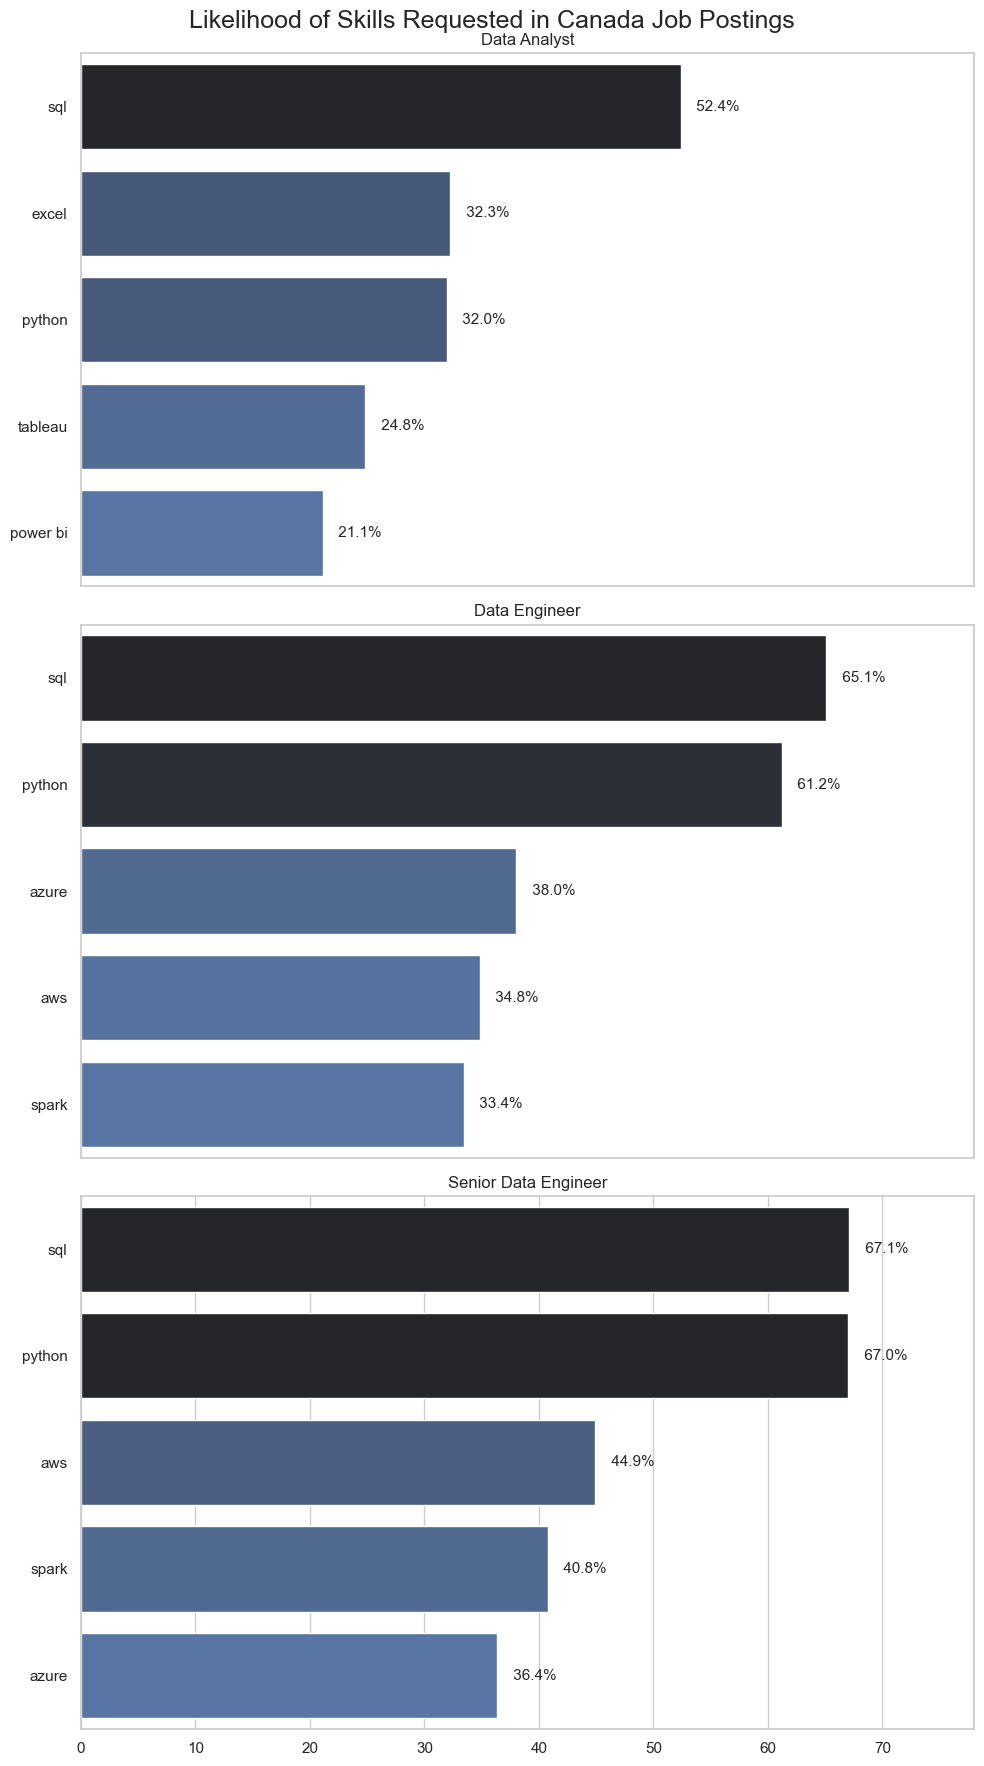

In [103]:
fig, ax = plt.subplots(len(job_titles), 1, figsize=(10, 6*len(job_titles)))


sns.set_theme(style='whitegrid')

for i, job_title in enumerate(job_titles):
    df_plot = df_skill_perc[df_skill_perc['job_title_short'] == job_title].head(5)
    
    sns.barplot(data=df_plot, x='skills_perc', y='job_skills', ax=ax[i], hue='skill_count', palette='dark:b_r')
    
    
    # Optional: Improve appearance
    ax[i].set_title(job_title)  # So highest skill is at the top
    ax[i].set_ylabel('')
    ax[i].set_xlabel('')
    ax[i].legend().set_visible(False)
    ax[i].set_xlim(0, 78)

    for index,value in enumerate(df_plot['skills_perc']):
        ax[i].text(
            x=value + 1,
            y =index,
            s = f'{value: .1f}%',
            va = 'center',
            fontsize = 11
        )
    if i !=len(job_titles) - 1:
        ax[i].set_xticks([])    

fig.suptitle('Likelihood of Skills Requested in Canada Job Postings', fontsize= 18)
fig.tight_layout()
plt.show()

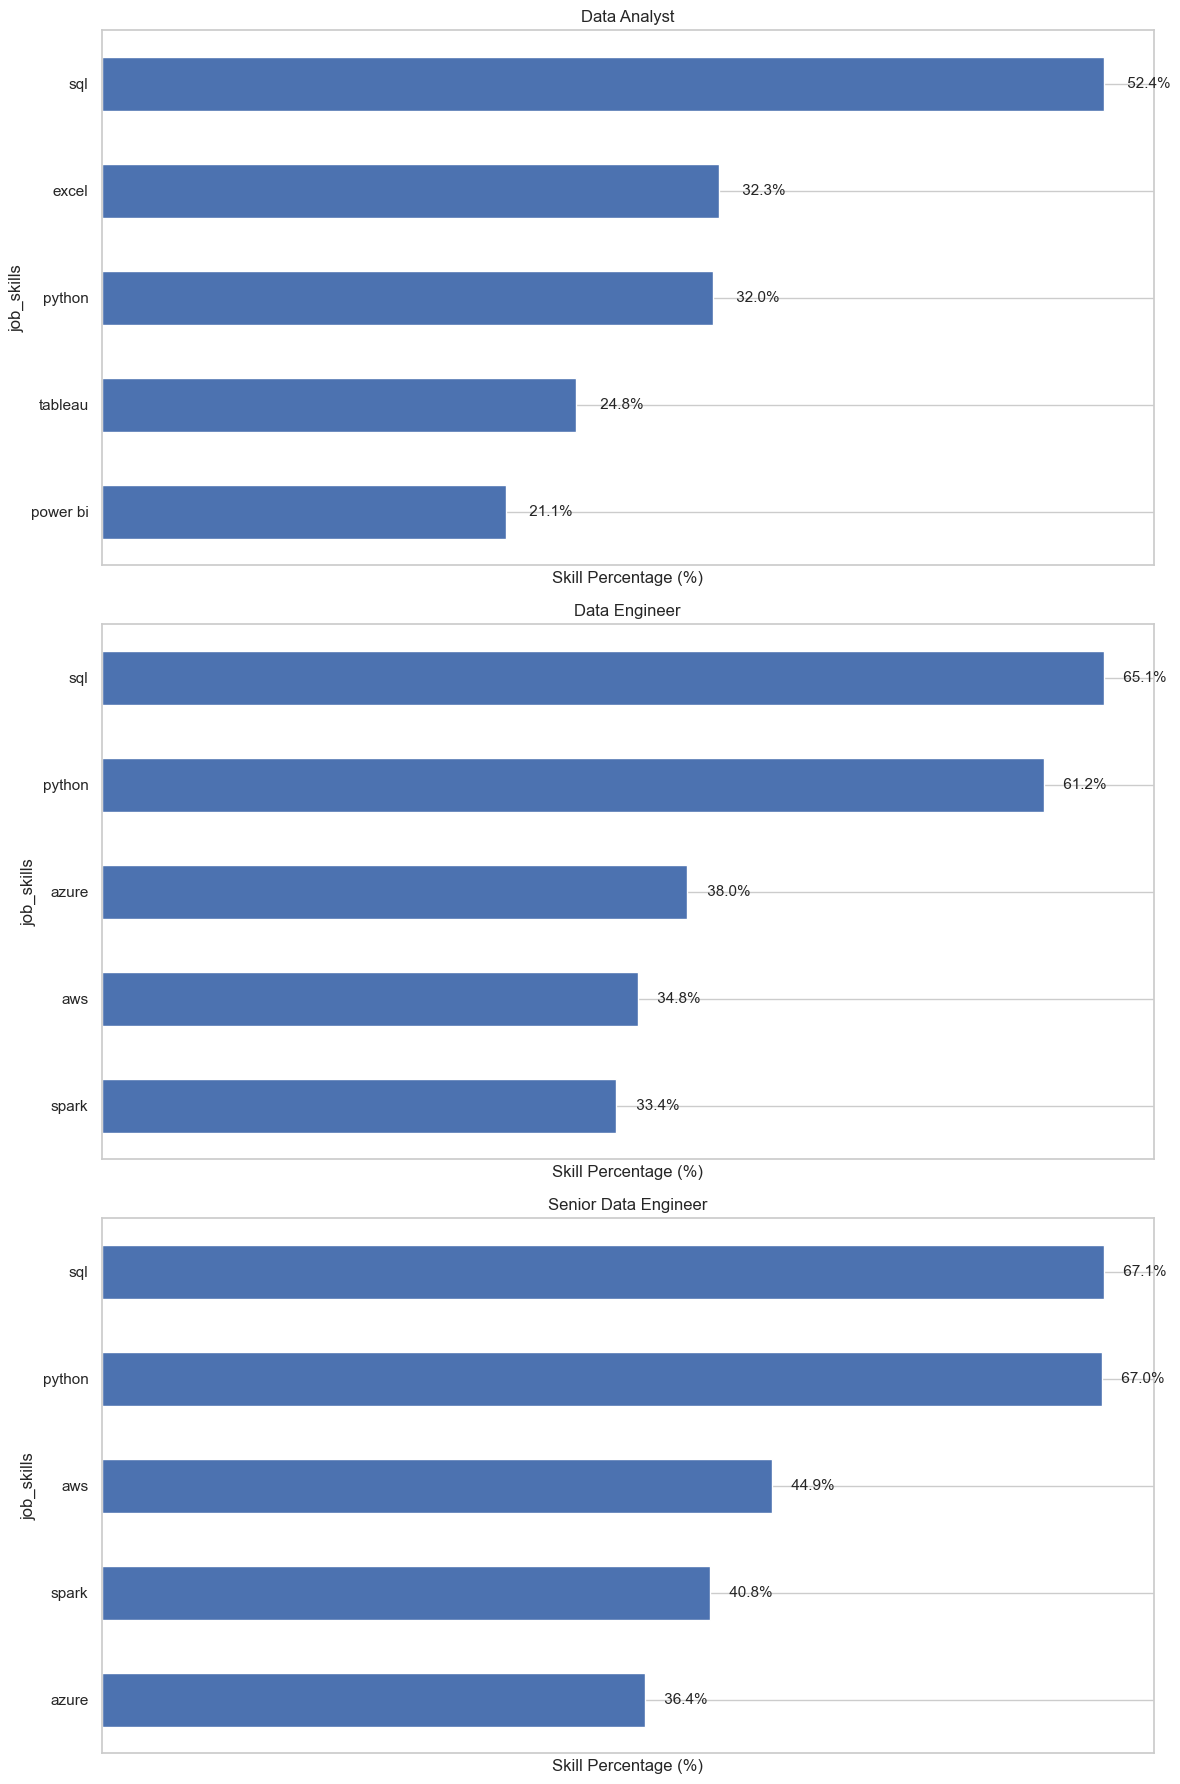

In [97]:
fig, ax = plt.subplots(len(job_titles), 1, figsize=(12, 6 * len(job_titles)))

for i, job_title in enumerate(job_titles):
    df_plot = df_skill_perc[df_skill_perc['job_title_short'] == job_title].head(5)
    
    df_plot.plot(
        kind='barh', 
        x='job_skills', 
        y='skills_perc',           # ← Fixed: added 's'
        ax=ax[i] if len(job_titles) > 1 else ax,
        title=job_title
    )
    
    # Improve appearance
    if len(job_titles) > 1:
        ax[i].invert_yaxis()
        ax[i].set_xlabel('Skill Percentage (%)')
        ax[i].legend().set_visible(False)
    else:
        ax.invert_yaxis()
        ax.set_xlabel('Skill Percentage (%)')
        ax.legend().set_visible(False)

    for index,value in enumerate(df_plot['skills_perc']):
        ax[i].text(
            x=value + 1,
            y =index,
            s = f'{value: .1f}%',
            va = 'center',
            fontsize = 11
        )

    ax[i].set_xticks([])  

plt.tight_layout()
plt.show()

C:\Users\HomePC\AppData\Local\Temp\ipykernel_13100\393469550.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\HomePC\AppData\Local\Temp\ipykernel_13100\393469550.py:36: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[i].legend().set_visible(False) if len(job_titles) > 1 else ax.legend().set_visible(False)
C:\Users\HomePC\AppData\Local\Temp\ipykernel_13100\393469550.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\HomePC\AppData\Local\Temp\ipykernel_13100\393469550.py:36: UserWarning: No artists with labels found to put in legend.  Note t

<Figure size 1200x1800 with 0 Axes>

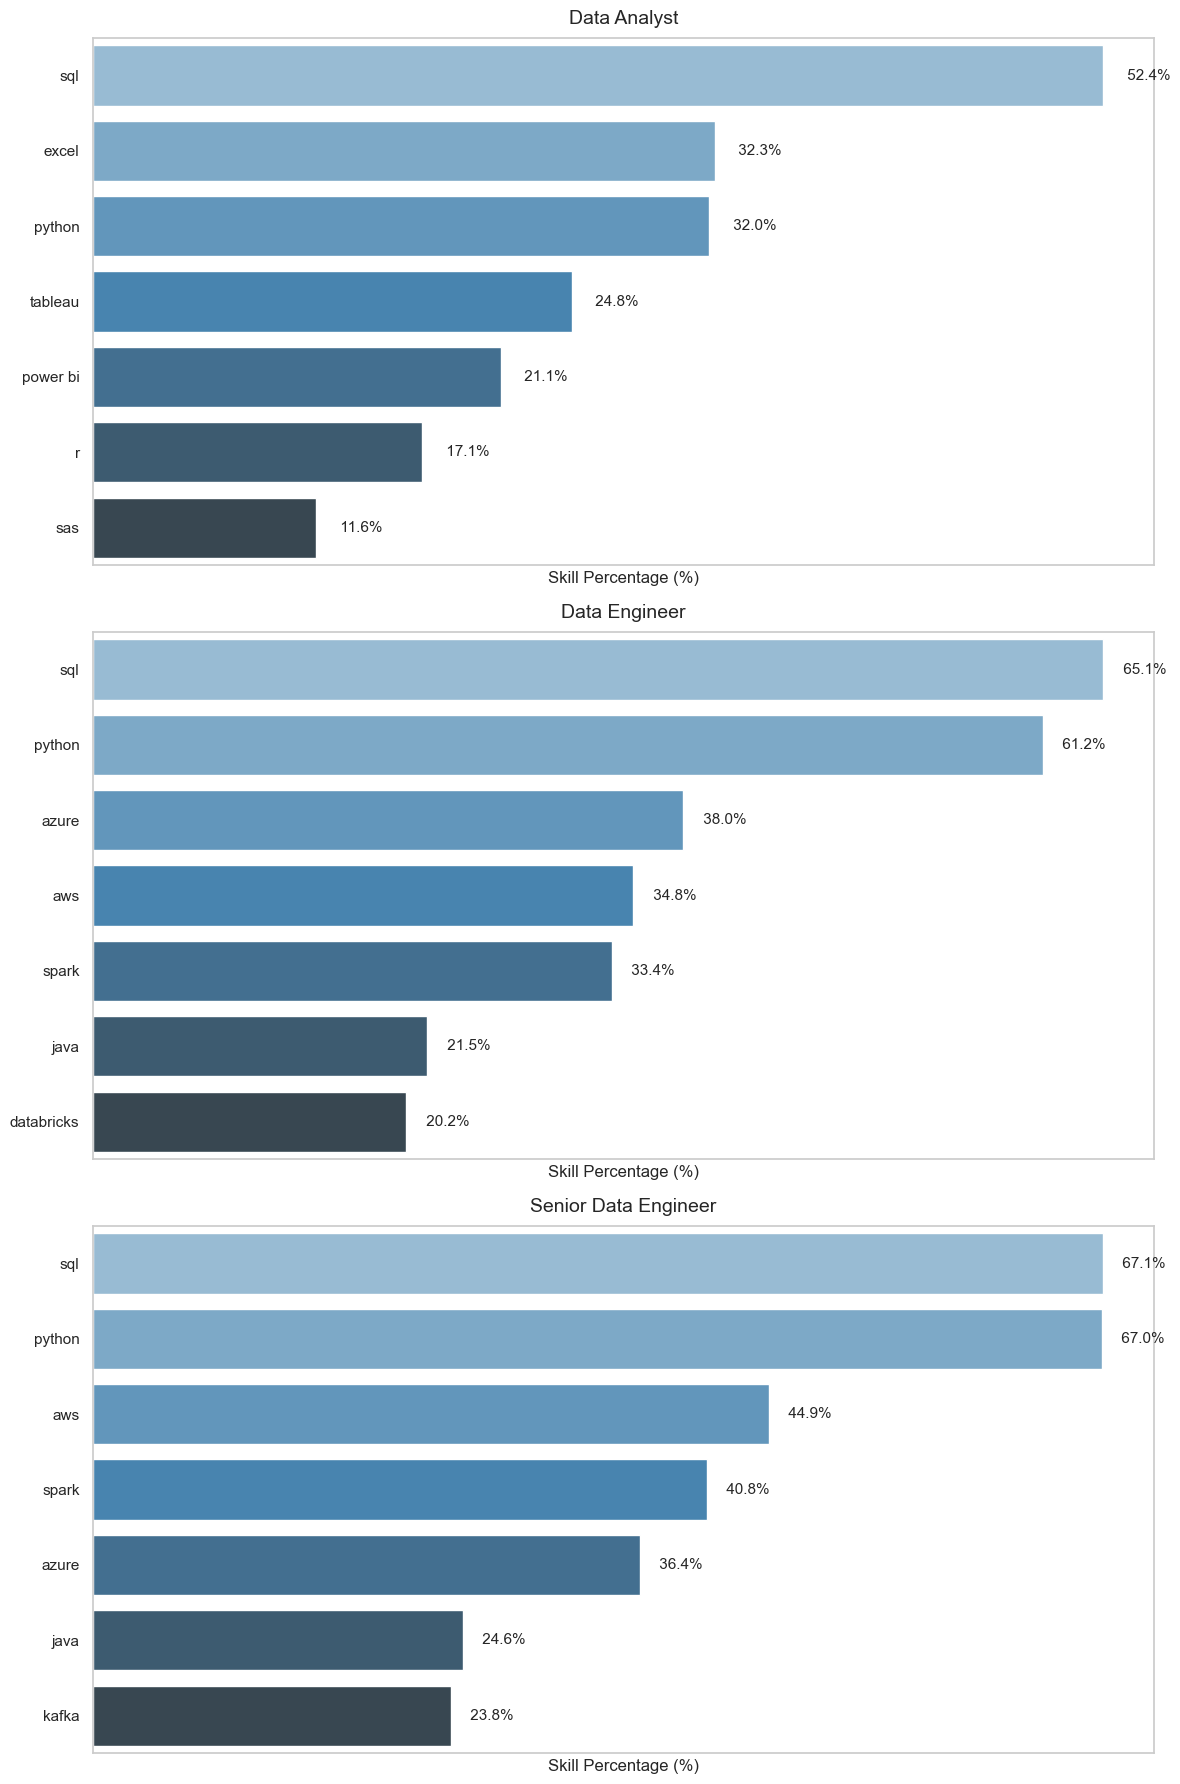

In [99]:


# Set style
sns.set_style("whitegrid")
plt.figure(figsize=(12, 6 * len(job_titles)))

# Create subplots with Seaborn
fig, ax = plt.subplots(len(job_titles), 1, figsize=(12, 6 * len(job_titles)))

for i, job_title in enumerate(job_titles):
    df_plot = df_skill_perc[df_skill_perc['job_title_short'] == job_title].head(7)  # increased to 7 skills
    
    sns.barplot(
        data=df_plot,
        y='job_skills',           # y-axis for horizontal bars
        x='skills_perc',          # x-axis = percentage
        ax=ax[i] if len(job_titles) > 1 else ax,
        palette="Blues_d"         # nice color scheme
    )

    ax[i].set_title(job_title, fontsize=14, pad=10) if len(job_titles) > 1 else ax.set_title(job_title, fontsize=14, pad=10)
    ax[i].set_xlabel('Skill Percentage (%)') if len(job_titles) > 1 else ax.set_xlabel('Skill Percentage (%)')
    ax[i].set_ylabel('') 

    for index,value in enumerate(df_plot['skills_perc']):
        ax[i].text(
            x=value + 1,
            y =index,
            s = f'{value: .1f}%',
            va = 'center',
            fontsize = 11
        )

    ax[i].set_xticks([])  

    
    # Remove legend
    ax[i].legend().set_visible(False) if len(job_titles) > 1 else ax.legend().set_visible(False)

plt.tight_layout()
plt.show()

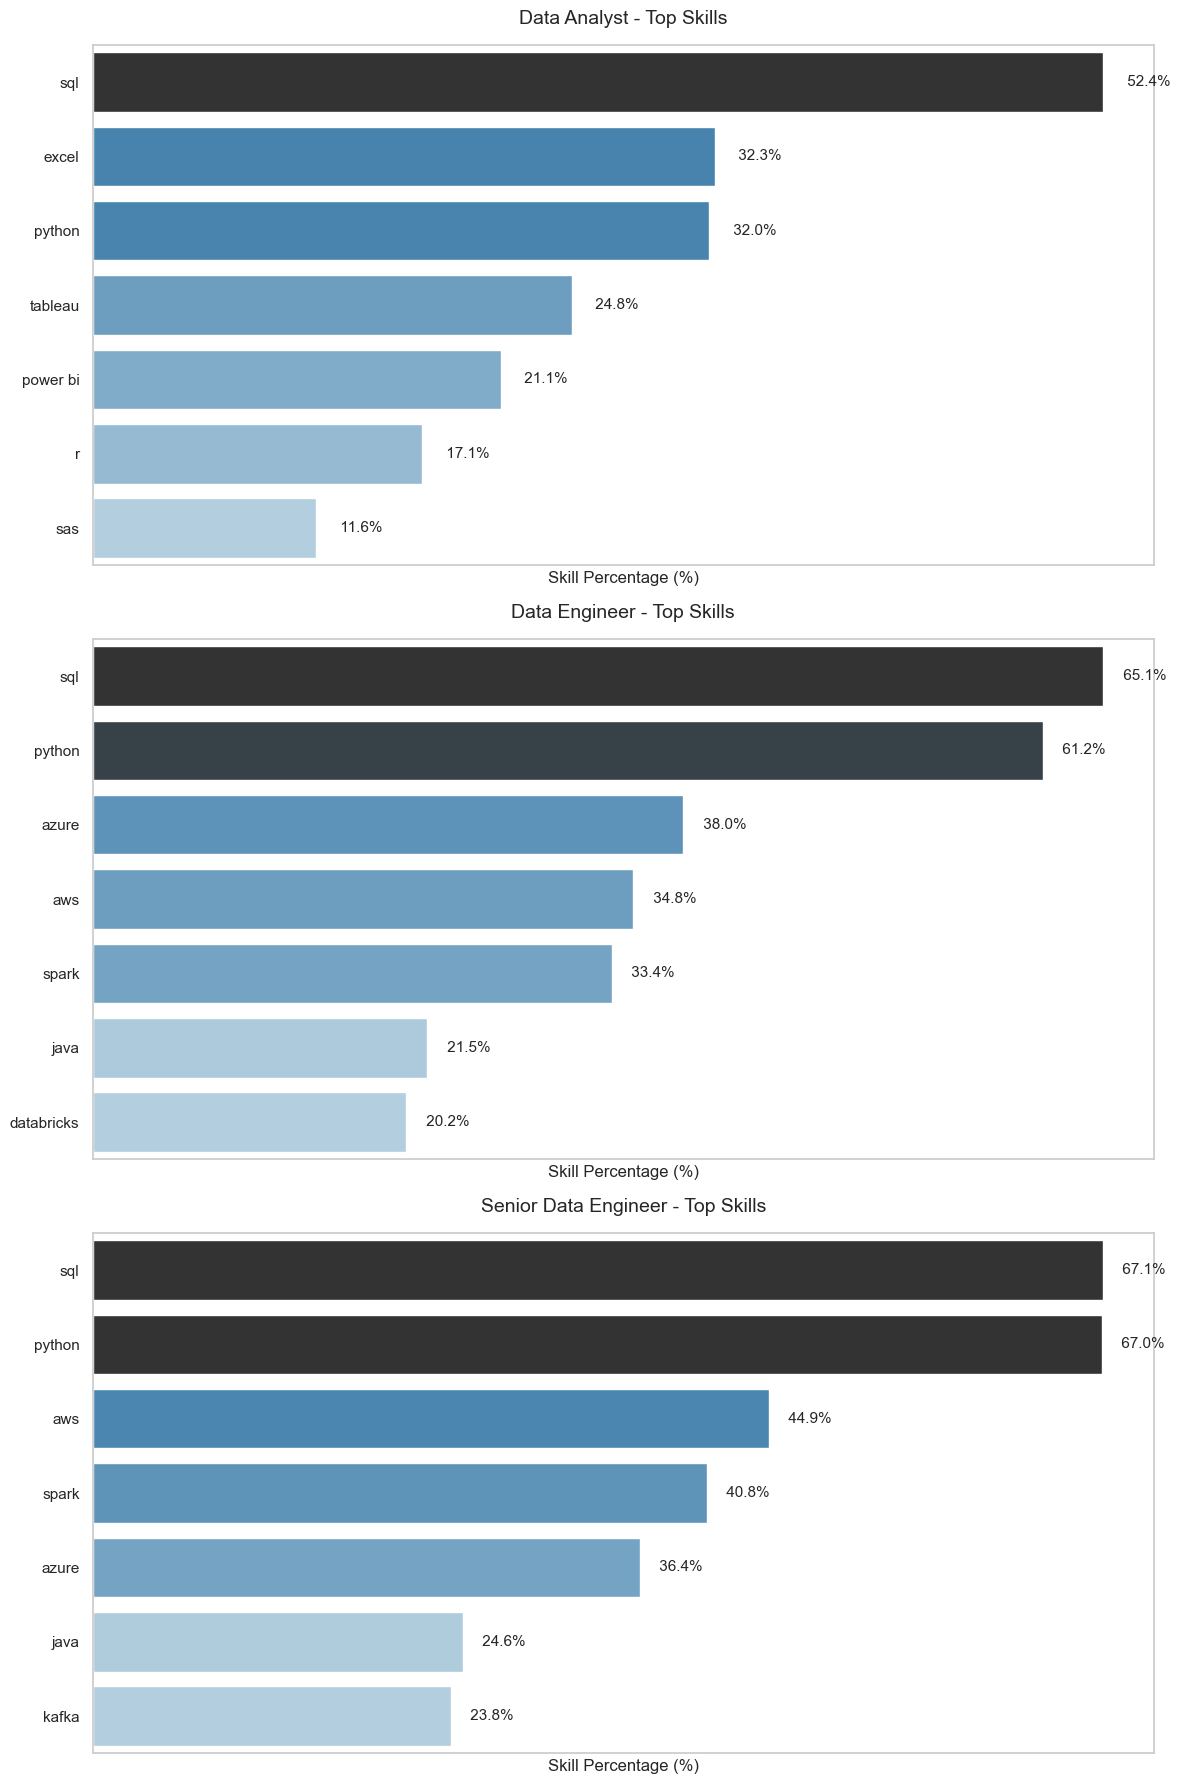

In [101]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")

fig, ax = plt.subplots(len(job_titles), 1, figsize=(12, 6 * len(job_titles)))

for i, job_title in enumerate(job_titles):
    # Get top 7 skills
    df_plot = df_skill_perc[df_skill_perc['job_title_short'] == job_title].head(7).copy()
    
    # Sort so highest skill is at the top
    df_plot = df_plot.sort_values(by='skills_perc', ascending=False)
    
    sns.barplot(
        data=df_plot,
        y='job_skills', 
        x='skills_perc',
        ax=ax[i] if len(job_titles) > 1 else ax,
        palette="Blues_d",           # Dark blue for top, lighter for bottom
        hue='skills_perc',           # This makes color intensity vary
        legend=False
    )
    
    # Titles and labels
    title_ax = ax[i] if len(job_titles) > 1 else ax
    title_ax.set_title(f"{job_title} - Top Skills", fontsize=14, pad=15)
    title_ax.set_xlabel('Skill Percentage (%)')
    title_ax.set_ylabel('')
    
    # Invert y-axis so top skill is at the very top
    for index,value in enumerate(df_plot['skills_perc']):
        ax[i].text(
            x=value + 1,
            y =index,
            s = f'{value: .1f}%',
            va = 'center',
            fontsize = 11
        )

    ax[i].set_xticks([])  

plt.tight_layout()
plt.show()

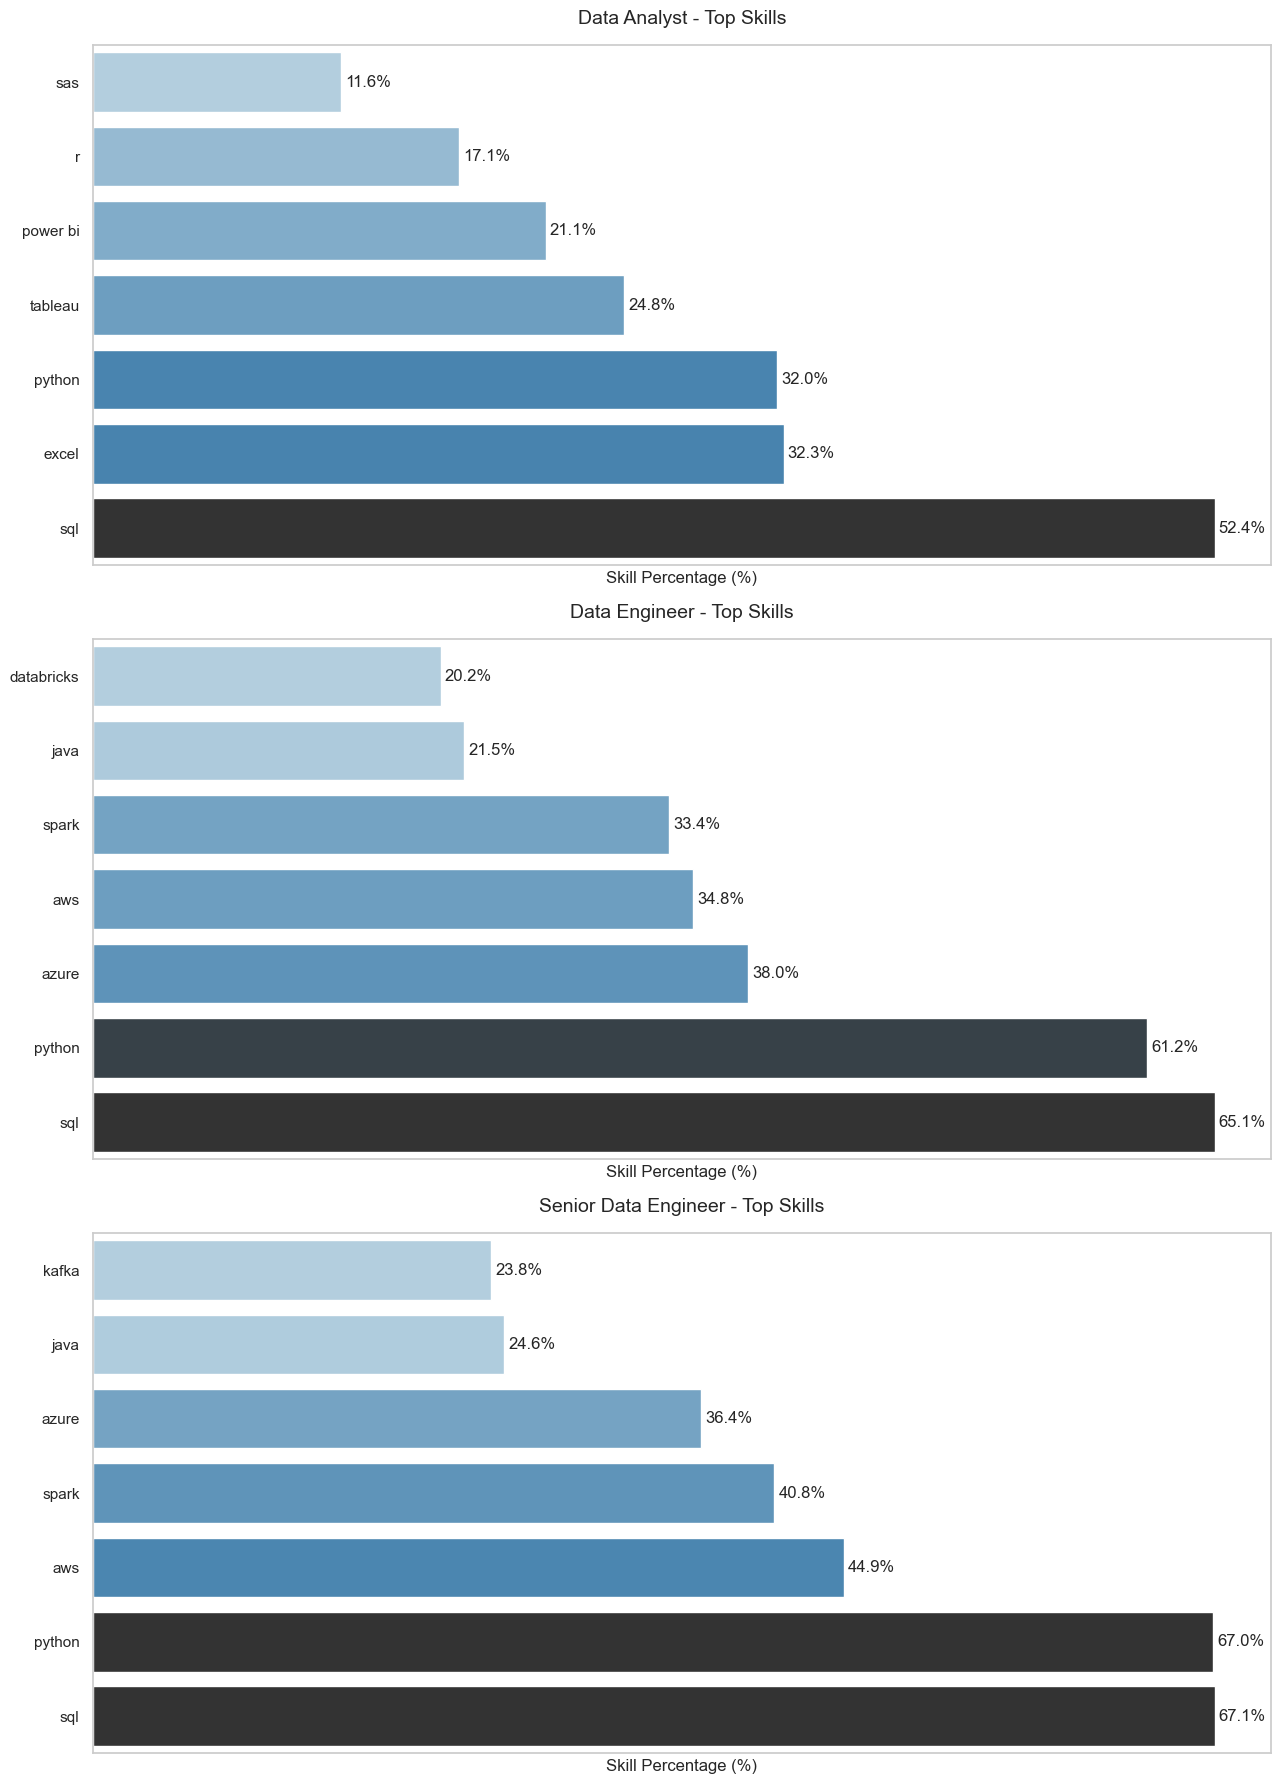

In [94]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")

fig, ax = plt.subplots(len(job_titles), 1, figsize=(13, 6 * len(job_titles)))

for i, job_title in enumerate(job_titles):
    # Get top 7 skills and sort so highest % is at the top
    df_plot = df_skill_perc[df_skill_perc['job_title_short'] == job_title].head(7).copy()
    df_plot = df_plot.sort_values(by='skills_perc', ascending=True)   # ascending = top at the top
    
    sns.barplot(
        data=df_plot,
        y='job_skills', 
        x='skills_perc',
        ax=ax[i] if len(job_titles) > 1 else ax,
        palette="Blues_d",      # Darkest color for highest skill
        hue='skills_perc',
        legend=False
    )
    
    # Labels and title
    current_ax = ax[i] if len(job_titles) > 1 else ax
    current_ax.set_title(f"{job_title} - Top Skills", fontsize=14, pad=15)
    current_ax.set_xlabel('Skill Percentage (%)')
    current_ax.set_ylabel('')
    
    # Optional: Add percentage labels on bars
    for container in current_ax.containers:
        current_ax.bar_label(container, fmt='%.1f%%', padding=3)

    ax[i].set_xticks([])    

plt.tight_layout()
plt.show()

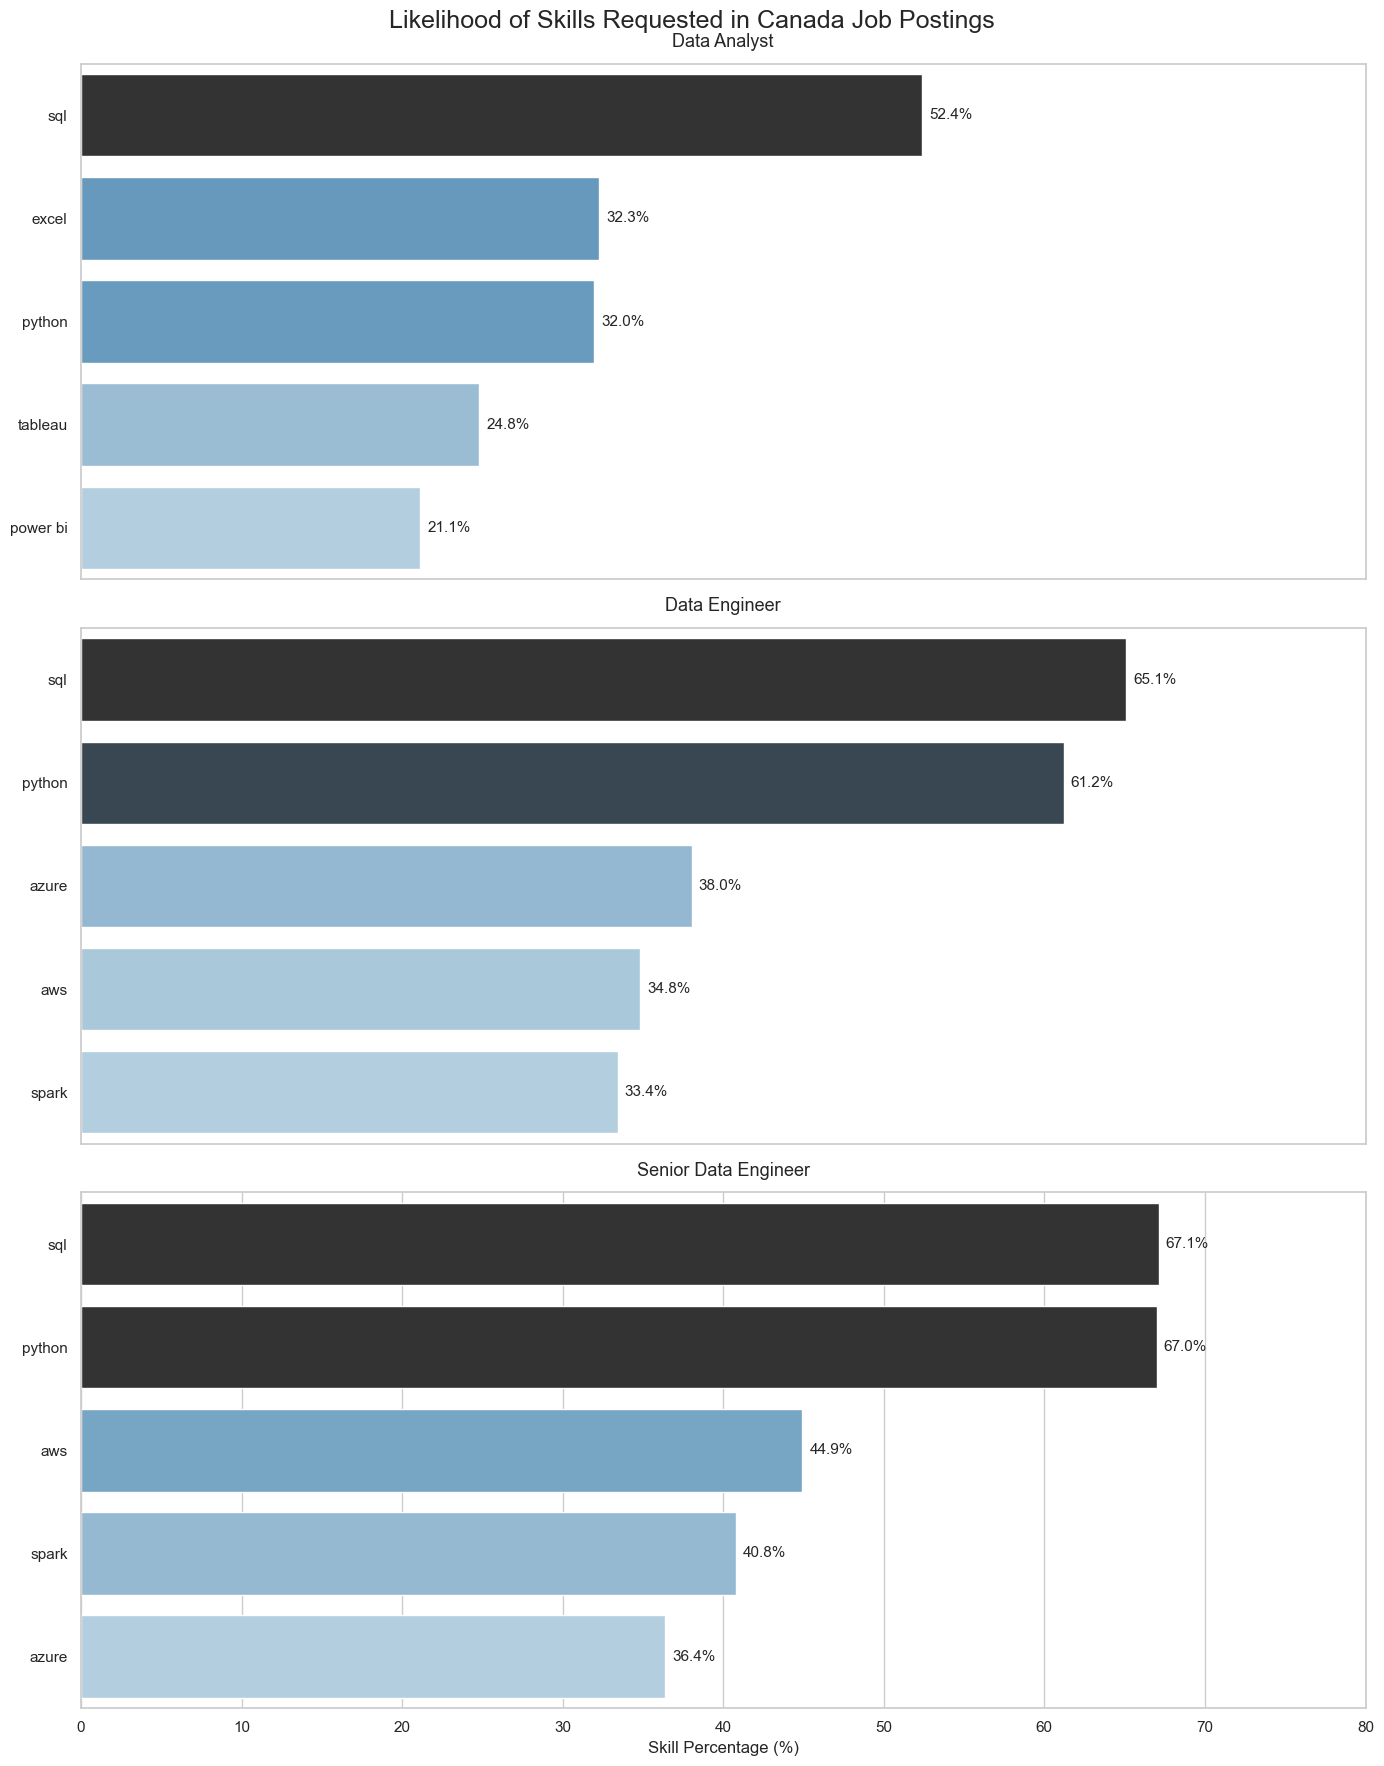

In [104]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style='whitegrid')

fig, ax = plt.subplots(len(job_titles), 1, figsize=(14, 6 * len(job_titles)))

for i, job_title in enumerate(job_titles):
    df_plot = df_skill_perc[df_skill_perc['job_title_short'] == job_title].head(5).copy()
    
    # Sort so highest skill is at the top
    df_plot = df_plot.sort_values(by='skills_perc', ascending=True)
    
    sns.barplot(
        data=df_plot, 
        x='skills_perc', 
        y='job_skills', 
        ax=ax[i],
        palette='Blues_d',           # Clean dark-to-light blue
        hue='skills_perc',           # Color intensity based on percentage
        legend=False
    )

    ax[i].invert_yaxis()
    
    # Improve appearance
    ax[i].set_title(job_title, fontsize=13, pad=12)
    ax[i].set_ylabel('')
    ax[i].set_xlabel('Skill Percentage (%)' if i == len(job_titles)-1 else '')
    ax[i].set_xlim(0, 80)
    
    # Add percentage labels on the bars
    for container in ax[i].containers:
        ax[i].bar_label(container, fmt='%.1f%%', padding=5, fontsize=11)

    if i !=len(job_titles) - 1:
        ax[i].set_xticks([])    

fig.suptitle('Likelihood of Skills Requested in Canada Job Postings', 
             fontsize=18, y=0.98)
fig.tight_layout()
plt.show()